# CNM Analysis for p+Pb LHC (5.02 & 8.16 TeV)
This notebook calculates and plots the coherent nuclear matter (CNM) effects (nPDF shadowing, coherent energy loss, and Cronin broadening) for charmonia in p+Pb collisions at LHC energies.

**Components:**
- **nPDF**: Shadowing using EPPS21
- **ELoss**: Coherent energy loss (Arleo-Peigné)
- **Broad**: Cronin pT broadening
- **ELoss + Broad**: Product of ELoss and Broadening factors
- **Total CNM**: nPDF × (ELoss × Broad)

**Styling**: Publication-ready plots with consistent color schemes.

## Setup & Calc

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dataclasses import replace

# Add paths for custom modules
sys.path.append('..')
sys.path.append('../eloss_code')
sys.path.append('../cnm_combine')
sys.path.append('../npdf_code')

from cnm_combine_fast import CNMCombineFast
from particle import Particle
from system_configs import LHCConfig as Config

import warnings
warnings.filterwarnings('ignore')

# Constants and Knobs
SAVE_PDF = True
SAVE_CSV = True
DPI = 150
ALPHA_BAND = 0.25
STEP_DEFAULT = True

# Color Scheme
COLORS = {
    'npdf': '#E69F00',
    'eloss': "#EC5B5B",
    'broad': "#2B2BEF",
    'eloss_broad': "#020202", # Product of loss and broad
    'cnm': 'gray'
}

COMP_LABELS = {
    'npdf': 'nPDF (EPPS21)',
    'eloss': 'Energy Loss',
    'broad': r'$p_T$ Broadening',
    'eloss_broad': r'ELoss + $p_T$ Broad',
    'cnm': 'Total CNM'
}

print("Setup complete.")

Setup complete.


In [2]:
def step_from_centers(xc, yc):
    """Construct edges for ax.step(where='post') from centers"""
    xc = np.asarray(xc, float)
    yc = np.asarray(yc, float)
    if xc.size < 2:
        dx = 1.0
        return np.array([xc[0]-0.5*dx, xc[0]+0.5*dx], float), np.array([yc[0], yc[0]], float)
    
    # Assuming equal spacing for convenience in finding edges
    dx = xc[1] - xc[0] 
    edges = np.concatenate([xc - 0.5*dx, [xc[-1] + 0.5*dx]])
    vals = np.concatenate([yc, [yc[-1]]])
    return edges, vals

def apply_pub_style(ax, xlim, ylim, xlabel, ylabel, tag=None, note=None):
    """Standardize plot appearance"""
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.axhline(1.0, color='k', ls='-', lw=0.8, alpha=0.5)
    
    ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=10)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    
    if tag:
        ax.text(0.95, 0.95, tag, transform=ax.transAxes, ha='right', va='top', 
                fontsize=12, fontweight='bold')
    if note:
        ax.text(0.05, 0.05, note, transform=ax.transAxes, ha='left', va='bottom', 
                fontsize=10, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# def plot_component_band(ax, x_cent, bands, comp, tag, step=True, **kwargs):
#     """Plot a single component band"""
#     Rc_dict, Rlo_dict, Rhi_dict = bands[comp]
#     xc = np.asarray(x_cent)
#     yc = np.asarray(Rc_dict[tag])
#     yl = np.asarray(Rlo_dict[tag])
#     yh = np.asarray(Rhi_dict[tag])
    
#     color = COLORS.get(comp, 'black')
#     label = COMP_LABELS.get(comp, comp)
    
#     if step:
#         xe, ye = step_from_centers(xc, yc)
#         _, yel = step_from_centers(xc, yl)
#         _, yeh = step_from_centers(xc, yh)
#         ax.step(xe, ye, where='post', color=color, lw=1.8, label=label)
#         ax.fill_between(xe, yel, yeh, step='post', color=color, alpha=ALPHA_BAND, lw=0)
#     else:
#         ax.plot(xc, yc, color=color, lw=1.8, label=label)
#         ax.fill_between(xc, yl, yh, color=color, alpha=ALPHA_BAND, lw=0)

def plot_component_band(ax, x_cent, bands, comp, tag, step=True):
    Rc_dict, Rlo_dict, Rhi_dict = bands[comp]
    xc = np.asarray(x_cent)
    yc = np.asarray(Rc_dict[tag])
    yl = np.asarray(Rlo_dict[tag])
    yh = np.asarray(Rhi_dict[tag])

    # Ensure lo <= hi always (fixes accidental swaps)
    yl2 = np.minimum(yl, yh)
    yh2 = np.maximum(yl, yh)

    # (Optional) if you want the band to always contain the central curve:
    yl2 = np.minimum(yl2, yc)
    yh2 = np.maximum(yh2, yc)
        
    color = COLORS.get(comp, 'black')
    label = COMP_LABELS.get(comp, comp)
    
    if step:
        xe, ye = step_from_centers(xc, yc)
        _, yel = step_from_centers(xc, yl2)
        _, yeh = step_from_centers(xc, yh2)
        ax.step(xe, ye, where='post', color=color, lw=1.7, label=label)
        ax.fill_between(xe, yel, yeh, step='post', color=color, alpha=ALPHA_BAND, lw=0)
    else:
        ax.plot(xc, yc, color=color, lw=1.7, label=label)
        ax.fill_between(xc, yl2, yh2, color=color, alpha=ALPHA_BAND, lw=0)

In [3]:
## Compute For later plotting
energies = [5.02, 8.16]
components = ['npdf', 'eloss', 'broad', 'eloss_broad', 'cnm']

# --- caches keyed by energy ---
cnm_by_E   = {}
outdir_by_E = {}

# results caches
res_y   = {}   # E -> (y_cent, labels, final_bands_y, y_edges)
res_pt  = {}   # E -> dict[y_window] -> (pT_cent, labels_pt, final_bands_pt, pT_edges)
res_cent = {}  # E -> dict[y_window] -> res_cent_dict

In [4]:
for energy in energies:
    print(f"\n[LOAD] {energy} TeV ...")
    outdir = Path(f'../outputs/cnm_combined/LHC_{energy}TeV')
    outdir.mkdir(parents=True, exist_ok=True)
    outdir_by_E[energy] = outdir

    particle = Particle(family='charmonia', state='avg')
    cnm = CNMCombineFast.from_defaults(
        energy=str(energy),
        family='charmonia',
        particle_state='avg',
        alpha_s_mode='constant',
        alpha0=0.5,
        cent_bins=Config.cent_bins_plotting
    )
    cnm_by_E[energy] = cnm
    print("Loading and calc done.")


[LOAD] 5.02 TeV ...
Loading and calc done.

[LOAD] 8.16 TeV ...
Loading and calc done.


## 1. $R_{pA}$ vs y (Integrated over pT [0, 10.0] GeV)

In [5]:
for energy in energies:
    print(f"[CALC y] {energy} TeV ...")
    cnm = cnm_by_E[energy]
    y_edges = np.linspace(-5.0, 5.0, 21)

    y_cent, labels, final_bands_y = cnm.cnm_vs_y(
        y_edges,
        pt_range_avg=Config.pt_range_integrated,
        components=components,
        include_mb=True
    )
    res_y[energy] = (y_cent, labels, final_bands_y, y_edges)

[CALC y] 5.02 TeV ...
[CALC y] 8.16 TeV ...


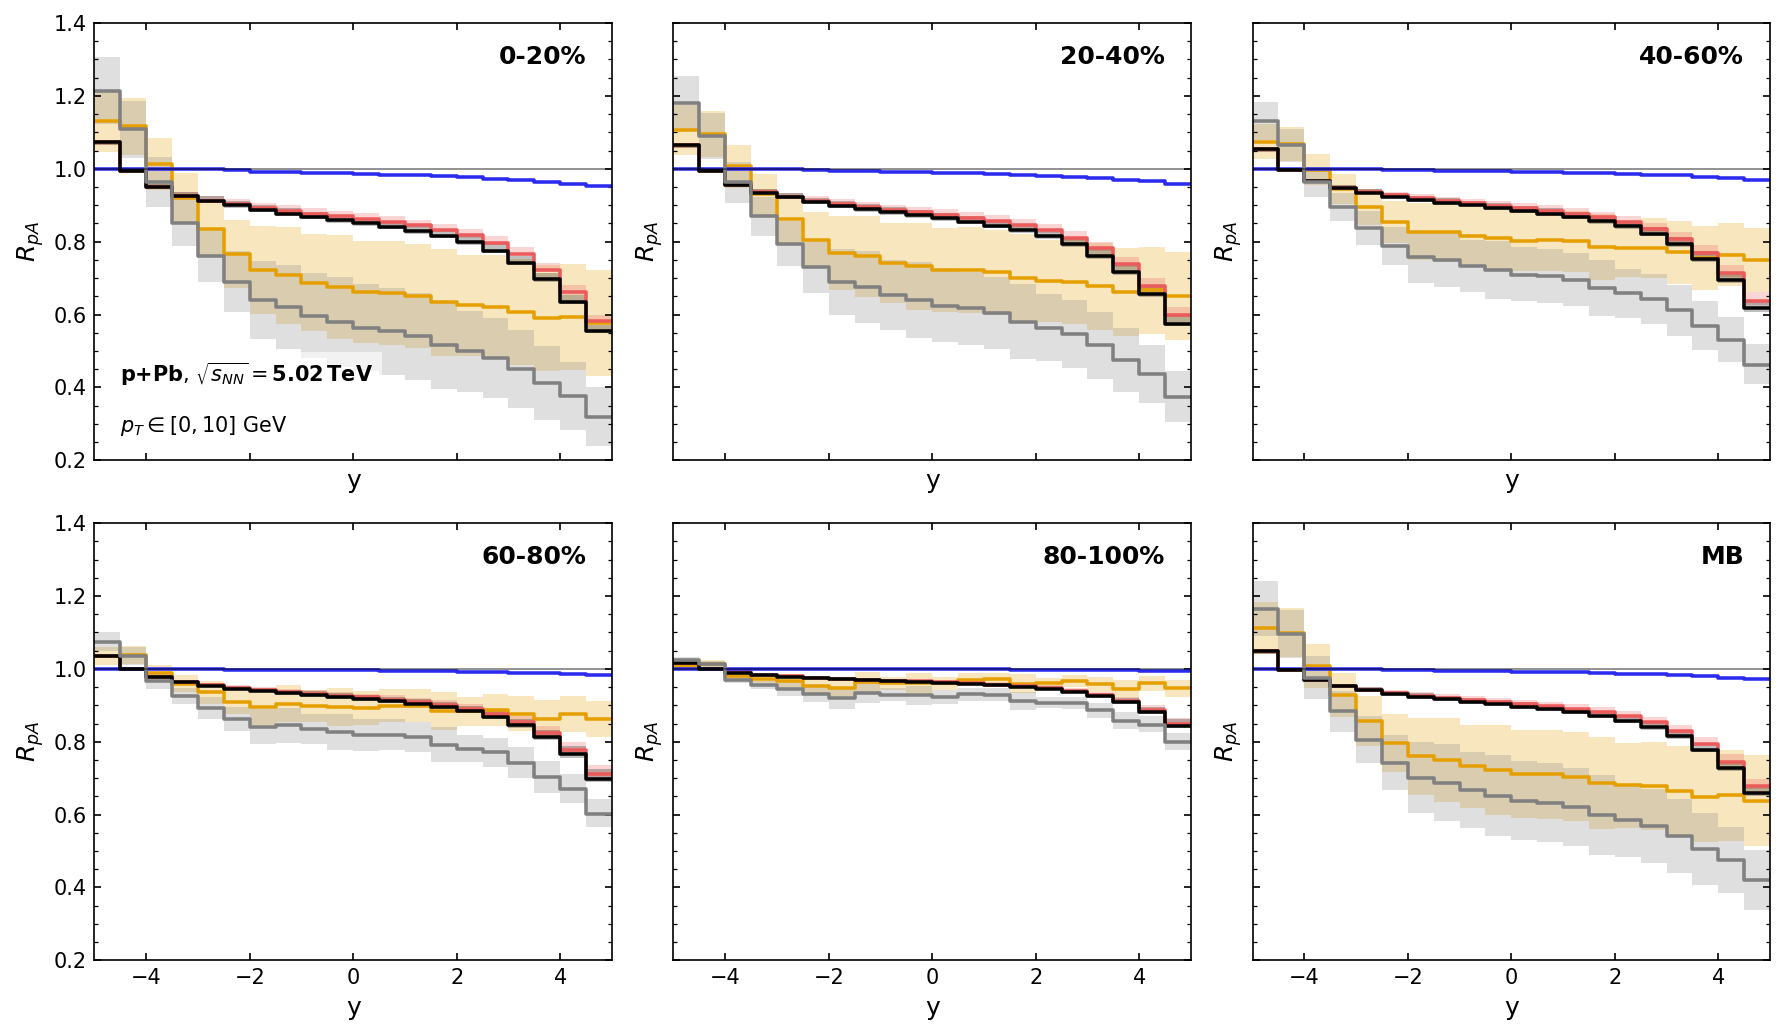

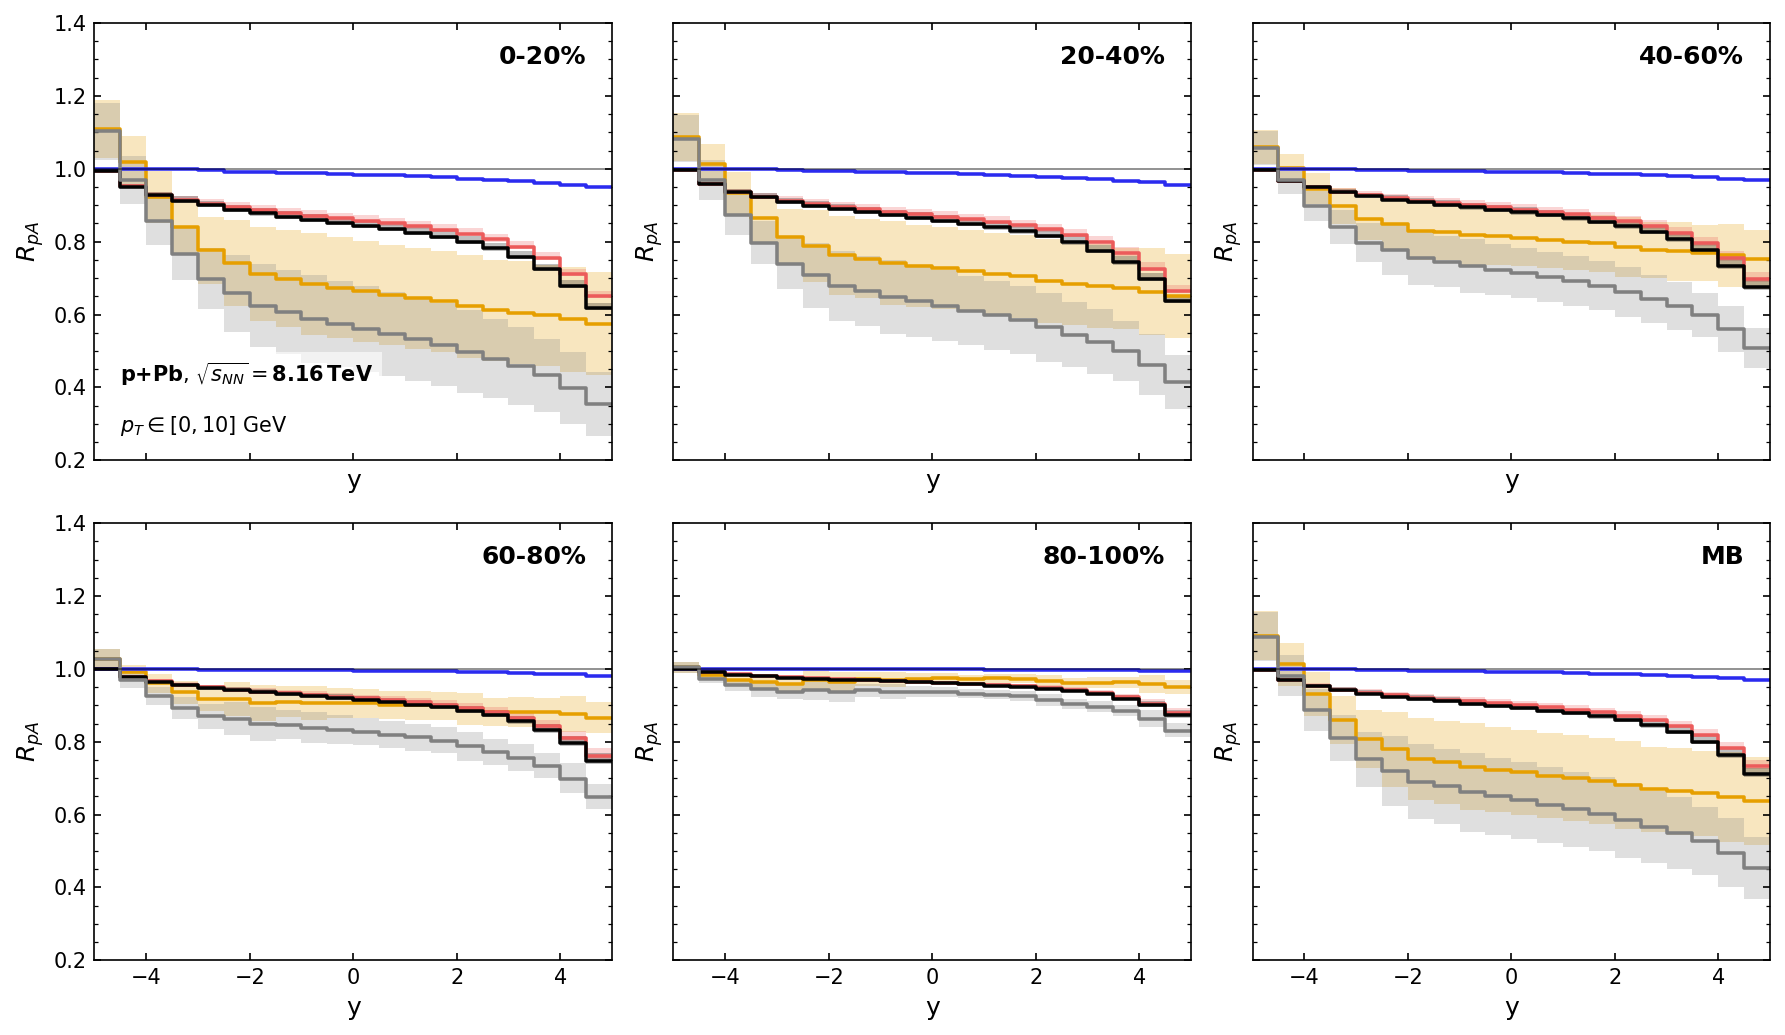

In [6]:
for energy in energies:
    outdir = outdir_by_E[energy]
    y_cent, labels, final_bands_y, y_edges = res_y[energy]

    tags_to_plot = labels + ['MB']
    n_pan = len(tags_to_plot)
    n_cols = 3
    n_rows = int(np.ceil(n_pan / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows),
                             dpi=DPI, sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    # note_y = rf"p+Pb, $\sqrt{{s_{{NN}}}} = {energy}$ TeV"+ "\n"+ "\n" + "$p_T \\in [0,10]$ GeV"
    note_y = rf"$\mathbf{{p{{+}}Pb}}$, $\sqrt{{s_{{NN}}}} = \mathbf{{{energy}}}\,\mathbf{{TeV}}$" \
         + "\n\n" + r"$p_T \in [0,10]$ GeV"
    for i, tag in enumerate(tags_to_plot):
        ax = axes[i]
        for comp in components:
            plot_component_band(ax, y_cent, final_bands_y, comp, tag, step=STEP_DEFAULT)
        apply_pub_style(ax, (-5, 5), (0.2, 1.4), 'y', r'$R_{pA}$',
                        tag=tag, note=note_y if i==0 else None)

    for k in range(n_pan, len(axes)):
        fig.delaxes(axes[k])

    fig.tight_layout()
    if SAVE_PDF:
        fig.savefig(outdir / f'RpA_vs_y_all_components_{energy}TeV.pdf', bbox_inches='tight')
    plt.show()


## 2. $R_{pA}$ vs $p_T$ in Rapidity Windows

In [7]:
for energy in energies:
    print(f"[CALC pT] {energy} TeV ...")
    cnm = cnm_by_E[energy]
    res_pt[energy] = {}

    for y_window in Config.rapidity_windows:
        y0, y1 = y_window
        w_name = f"{y0}<y<{y1}"
        print(f"  window {w_name}")

        pT_edges = np.arange(0, 20.5, 2.5)
        pT_cent, labels_pt, final_bands_pt = cnm.cnm_vs_pT(
            y_window, pT_edges,
            components=components,
            include_mb=True
        )
        res_pt[energy][y_window] = (pT_cent, labels_pt, final_bands_pt, pT_edges)
    print("pT calc done.")

[CALC pT] 5.02 TeV ...
  window -4.46<y<-2.96
  window -1.37<y<0.43
  window 2.03<y<3.53
pT calc done.
[CALC pT] 8.16 TeV ...
  window -4.46<y<-2.96
  window -1.37<y<0.43
  window 2.03<y<3.53
pT calc done.


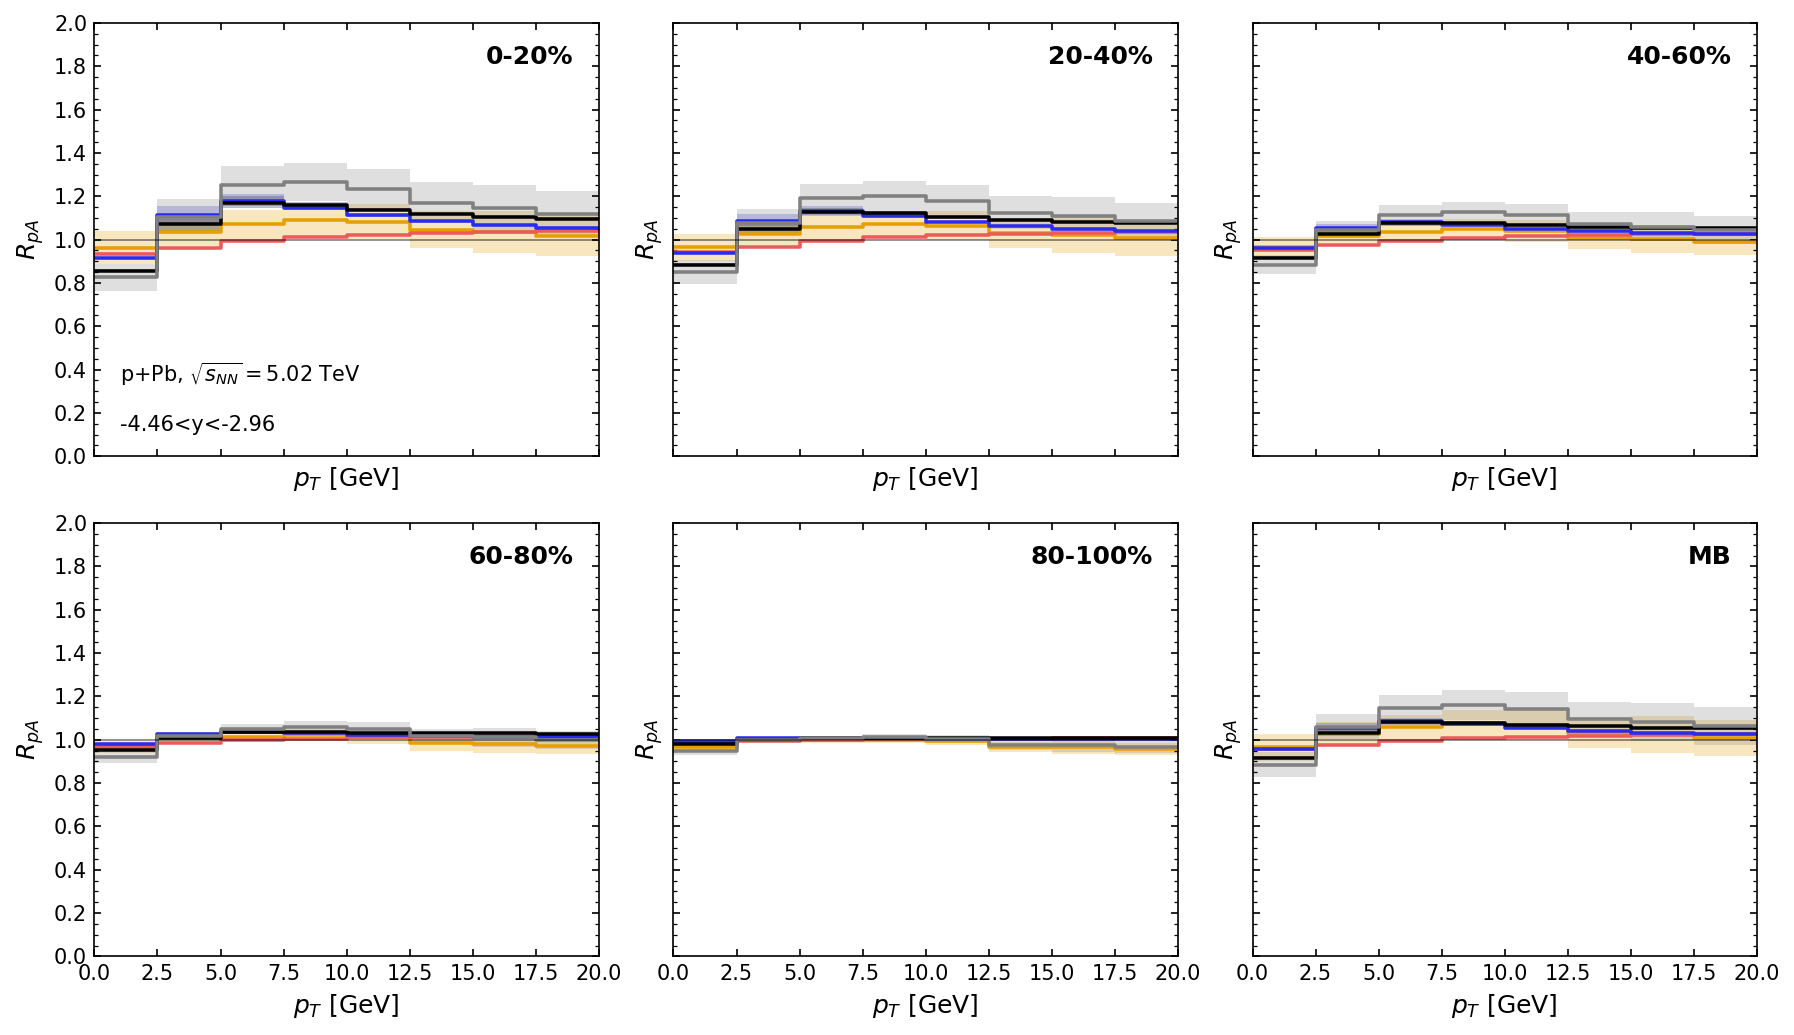

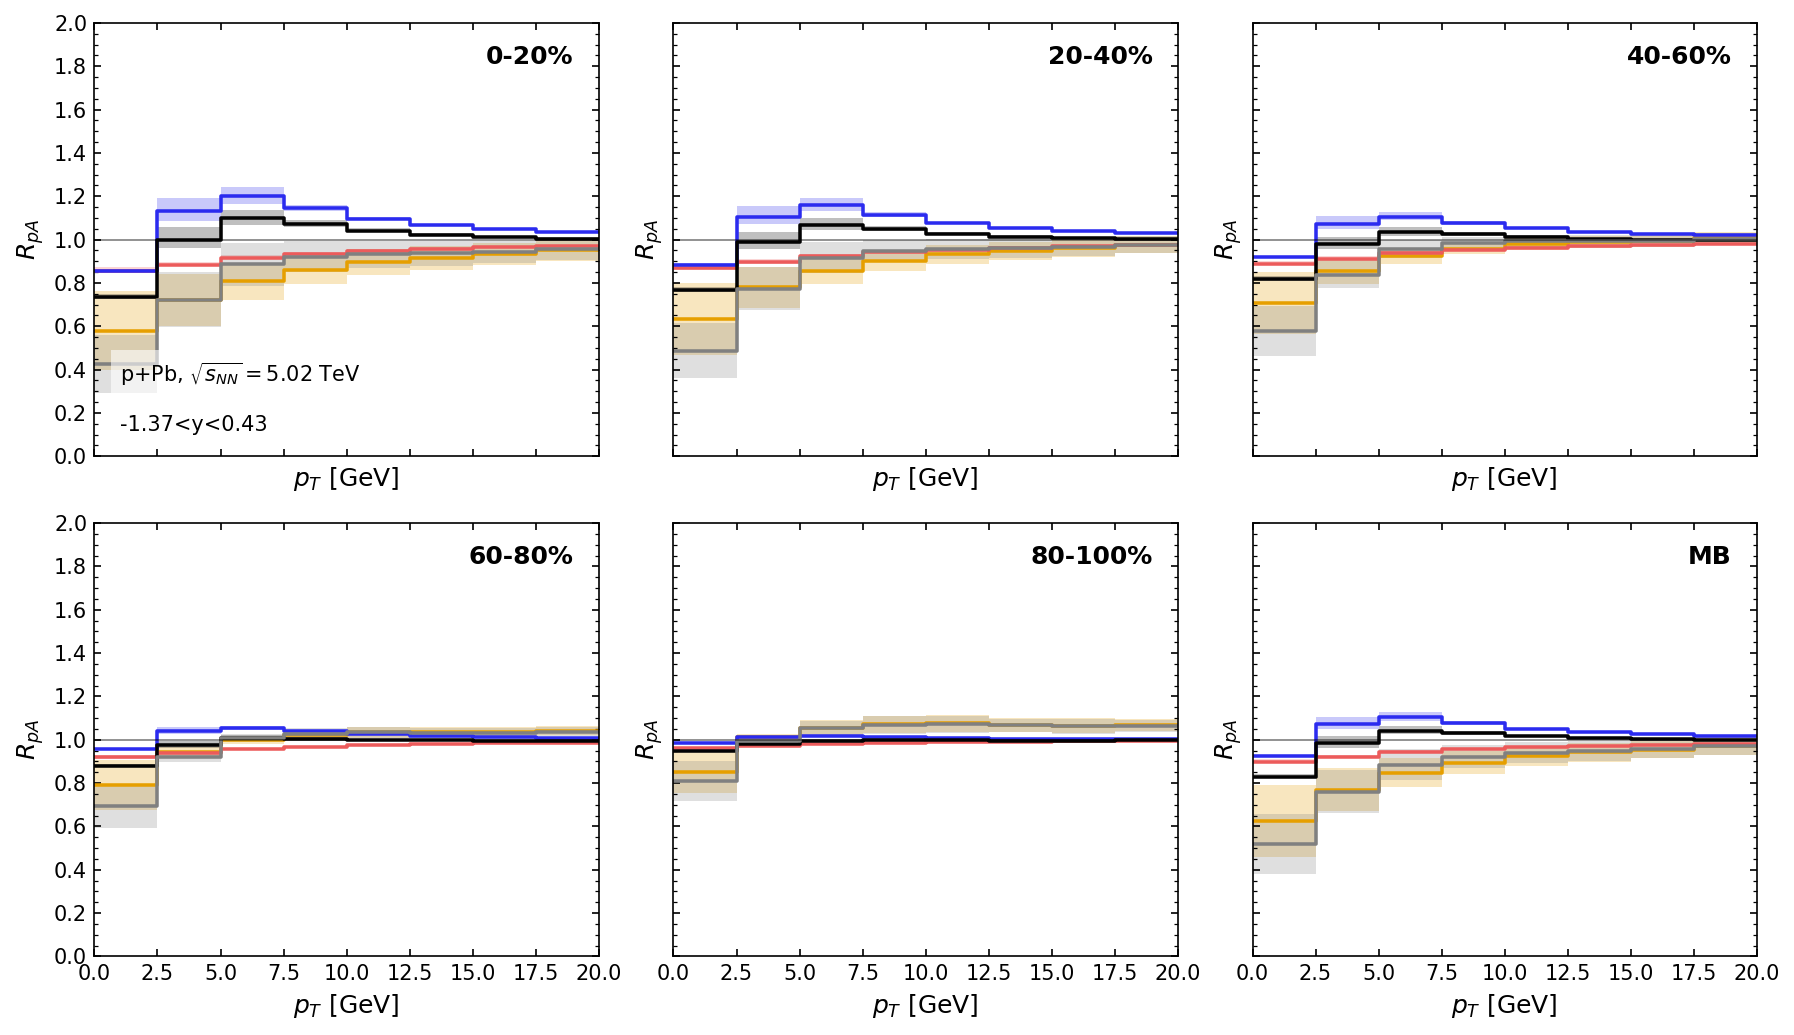

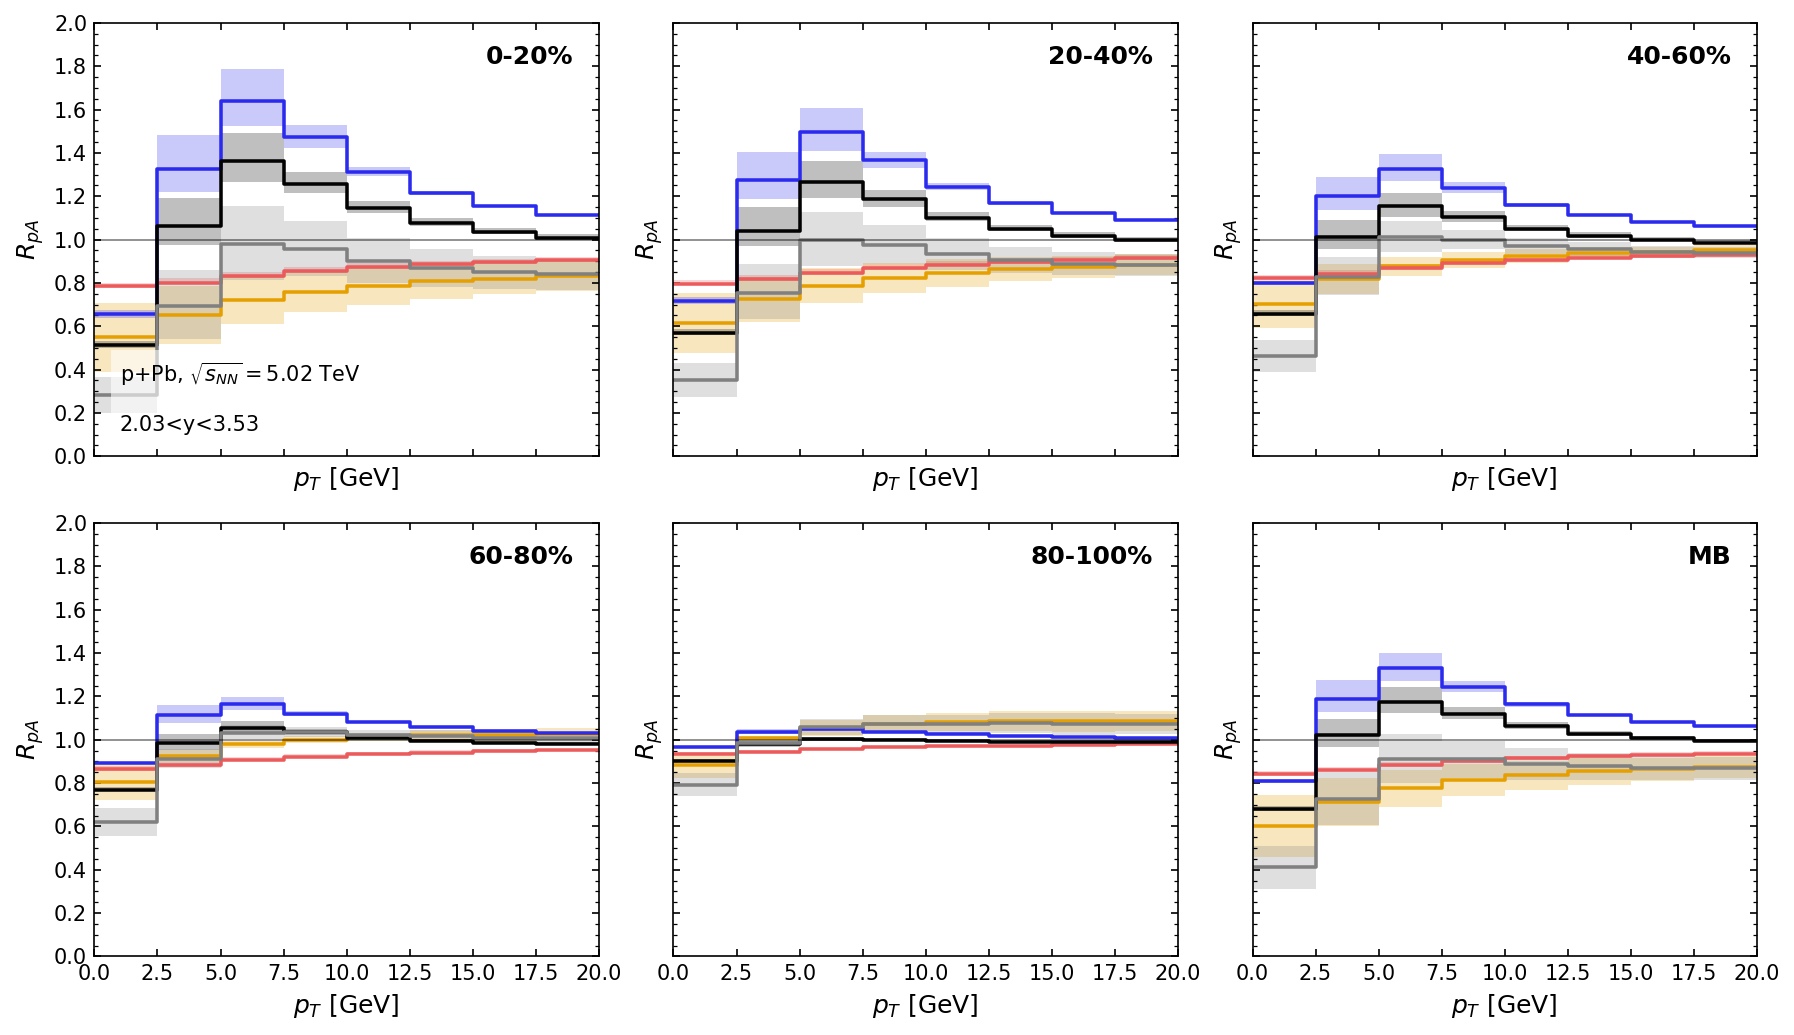

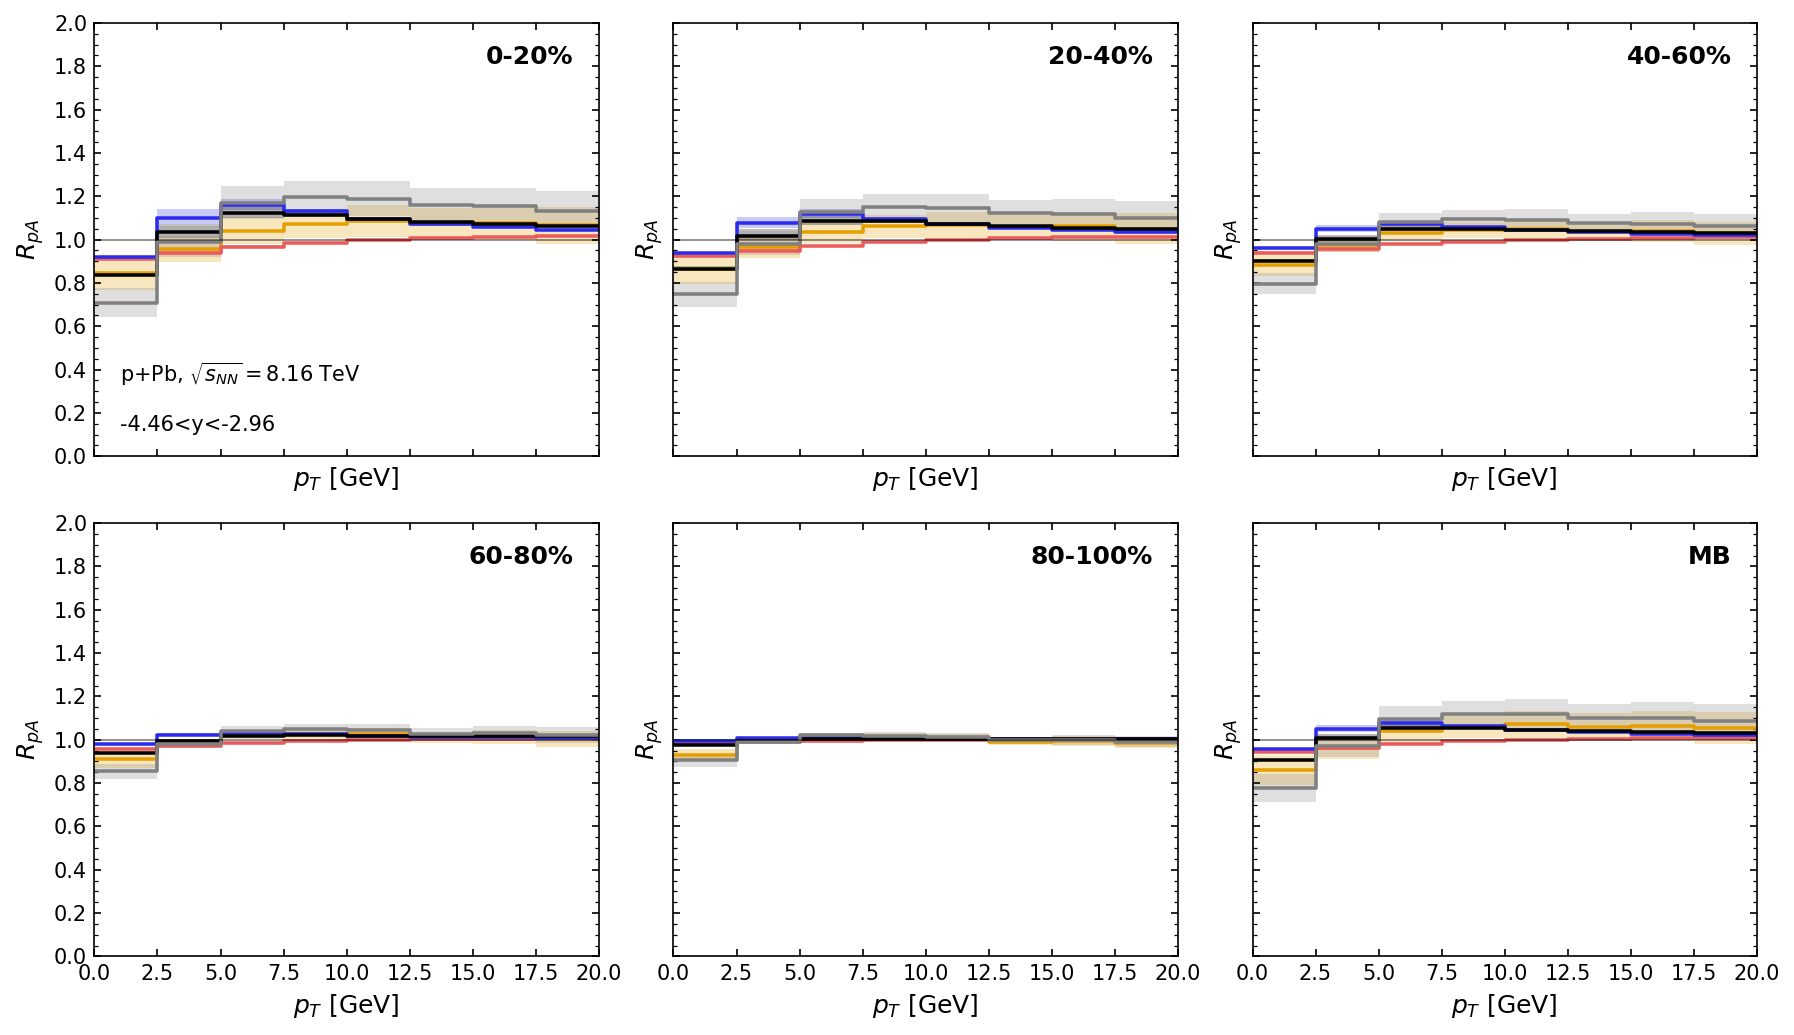

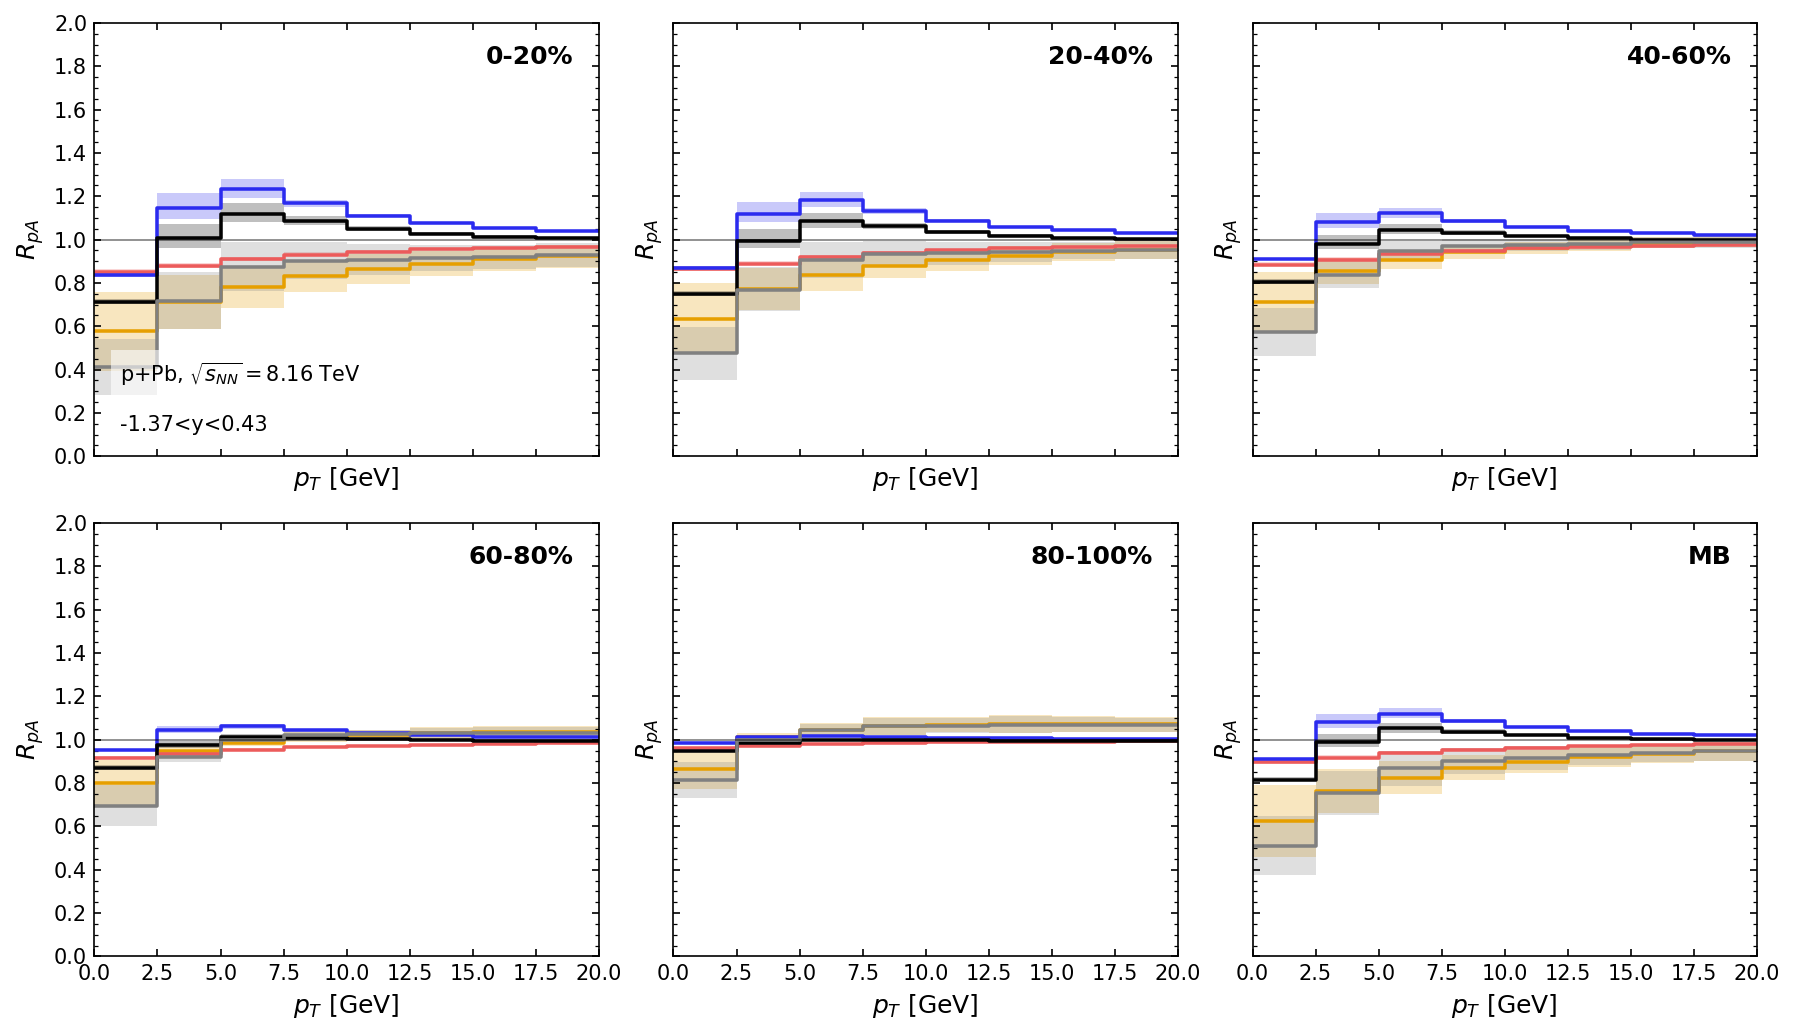

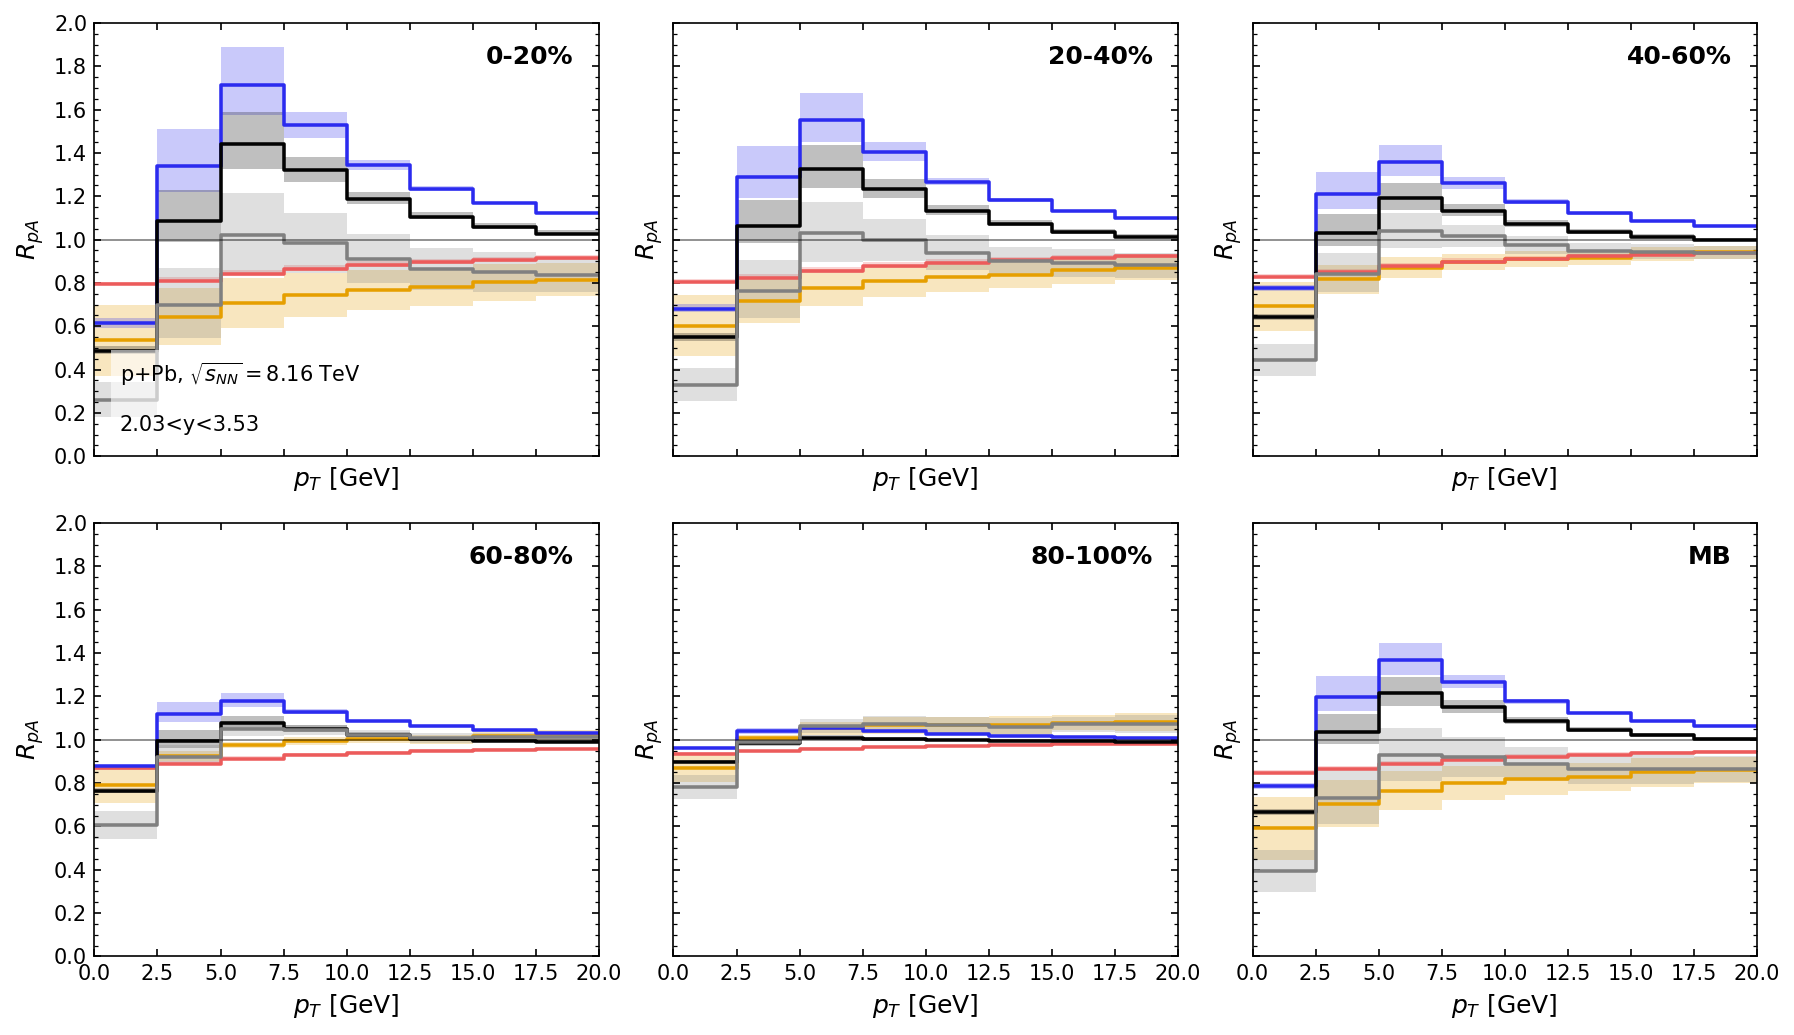

In [8]:
for energy in energies:
    outdir = outdir_by_E[energy]

    # reuse tags from y-calc (labels identical logic)
    _, labels, _, _ = res_y[energy]
    tags_to_plot = labels + ['MB']
    n_pan = len(tags_to_plot)
    n_cols = 3
    n_rows = int(np.ceil(n_pan / n_cols))

    for y_window in Config.rapidity_windows:
        y0, y1 = y_window
        w_name = f"{y0}<y<{y1}"

        pT_cent, labels_pt, final_bands_pt, pT_edges = res_pt[energy][y_window]

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows),
                                 dpi=DPI, sharex=True, sharey=True)
        axes = np.atleast_1d(axes).ravel()

        note_pt = rf"p+Pb, $\sqrt{{s_{{NN}}}} = {energy}$ TeV" + "\n" + "\n" + f"{w_name}"
        for i, tag in enumerate(tags_to_plot):
            ax = axes[i]
            for comp in components:
                plot_component_band(ax, pT_cent, final_bands_pt, comp, tag, step=STEP_DEFAULT)
            apply_pub_style(ax, (0., 20), (0.0, 2.0), '$p_T$ [GeV]', r'$R_{pA}$',
                            tag=tag, note=note_pt if i==0 else None)

        for k in range(n_pan, len(axes)):
            fig.delaxes(axes[k])

        fig.tight_layout()
        safe_w = w_name.replace('<','').replace('>','').replace('/','_')
        if SAVE_PDF:
            fig.savefig(outdir / f'RpA_vs_pt_all_components_{safe_w}_{energy}TeV.pdf', bbox_inches='tight')
        plt.show()

[PLOT pT MASTER GRID] 5.02 TeV ...


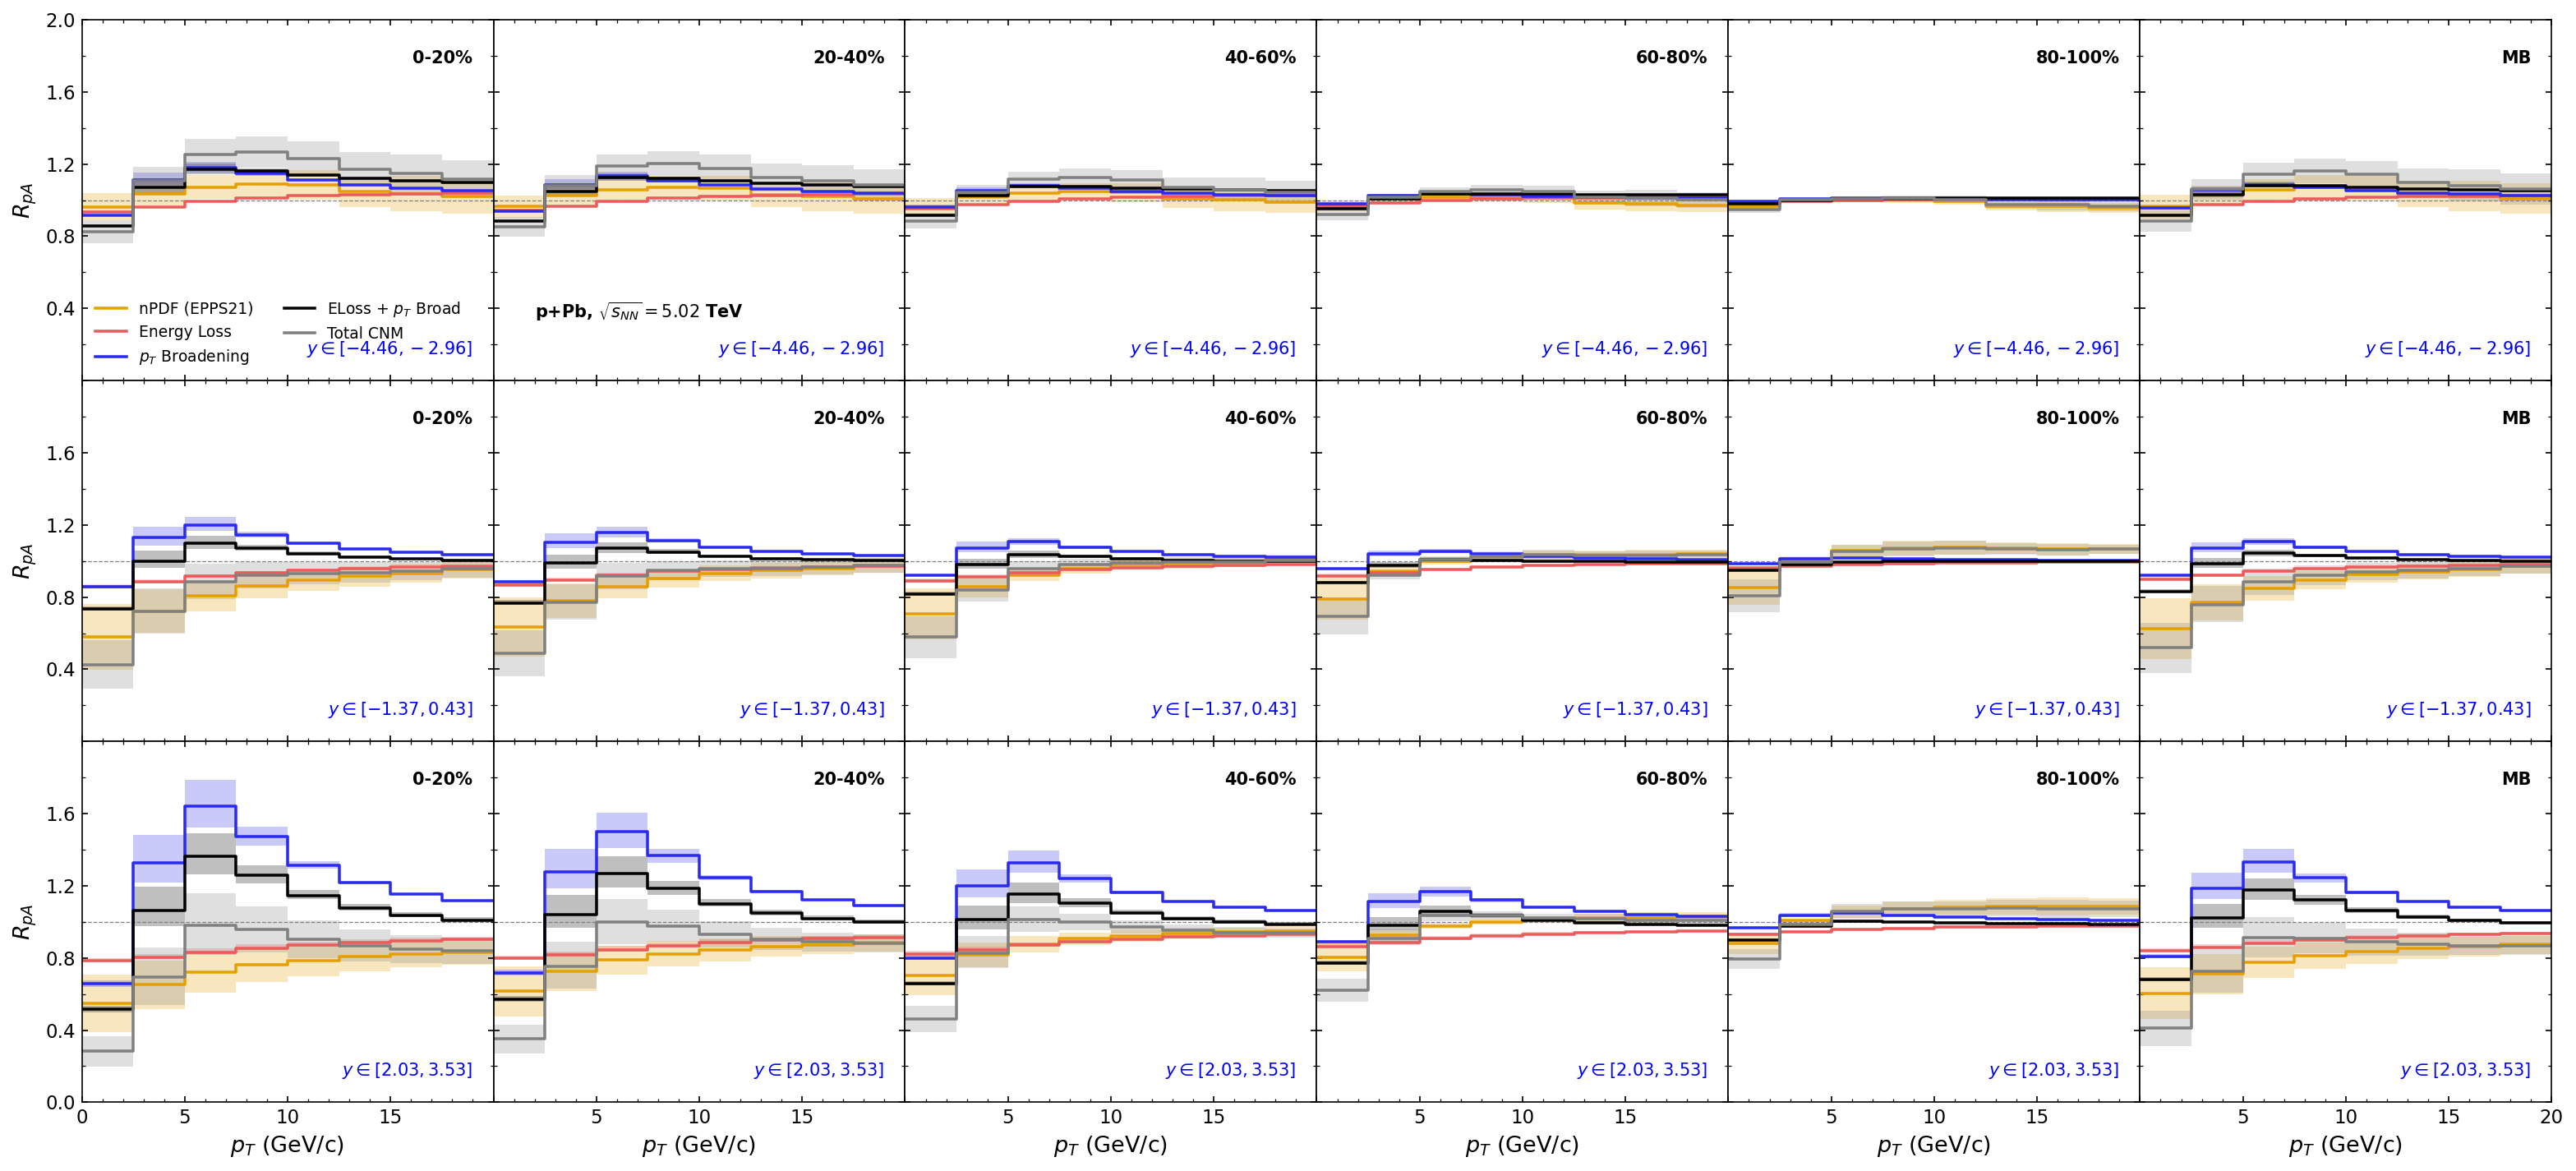

[PLOT pT MASTER GRID] 8.16 TeV ...


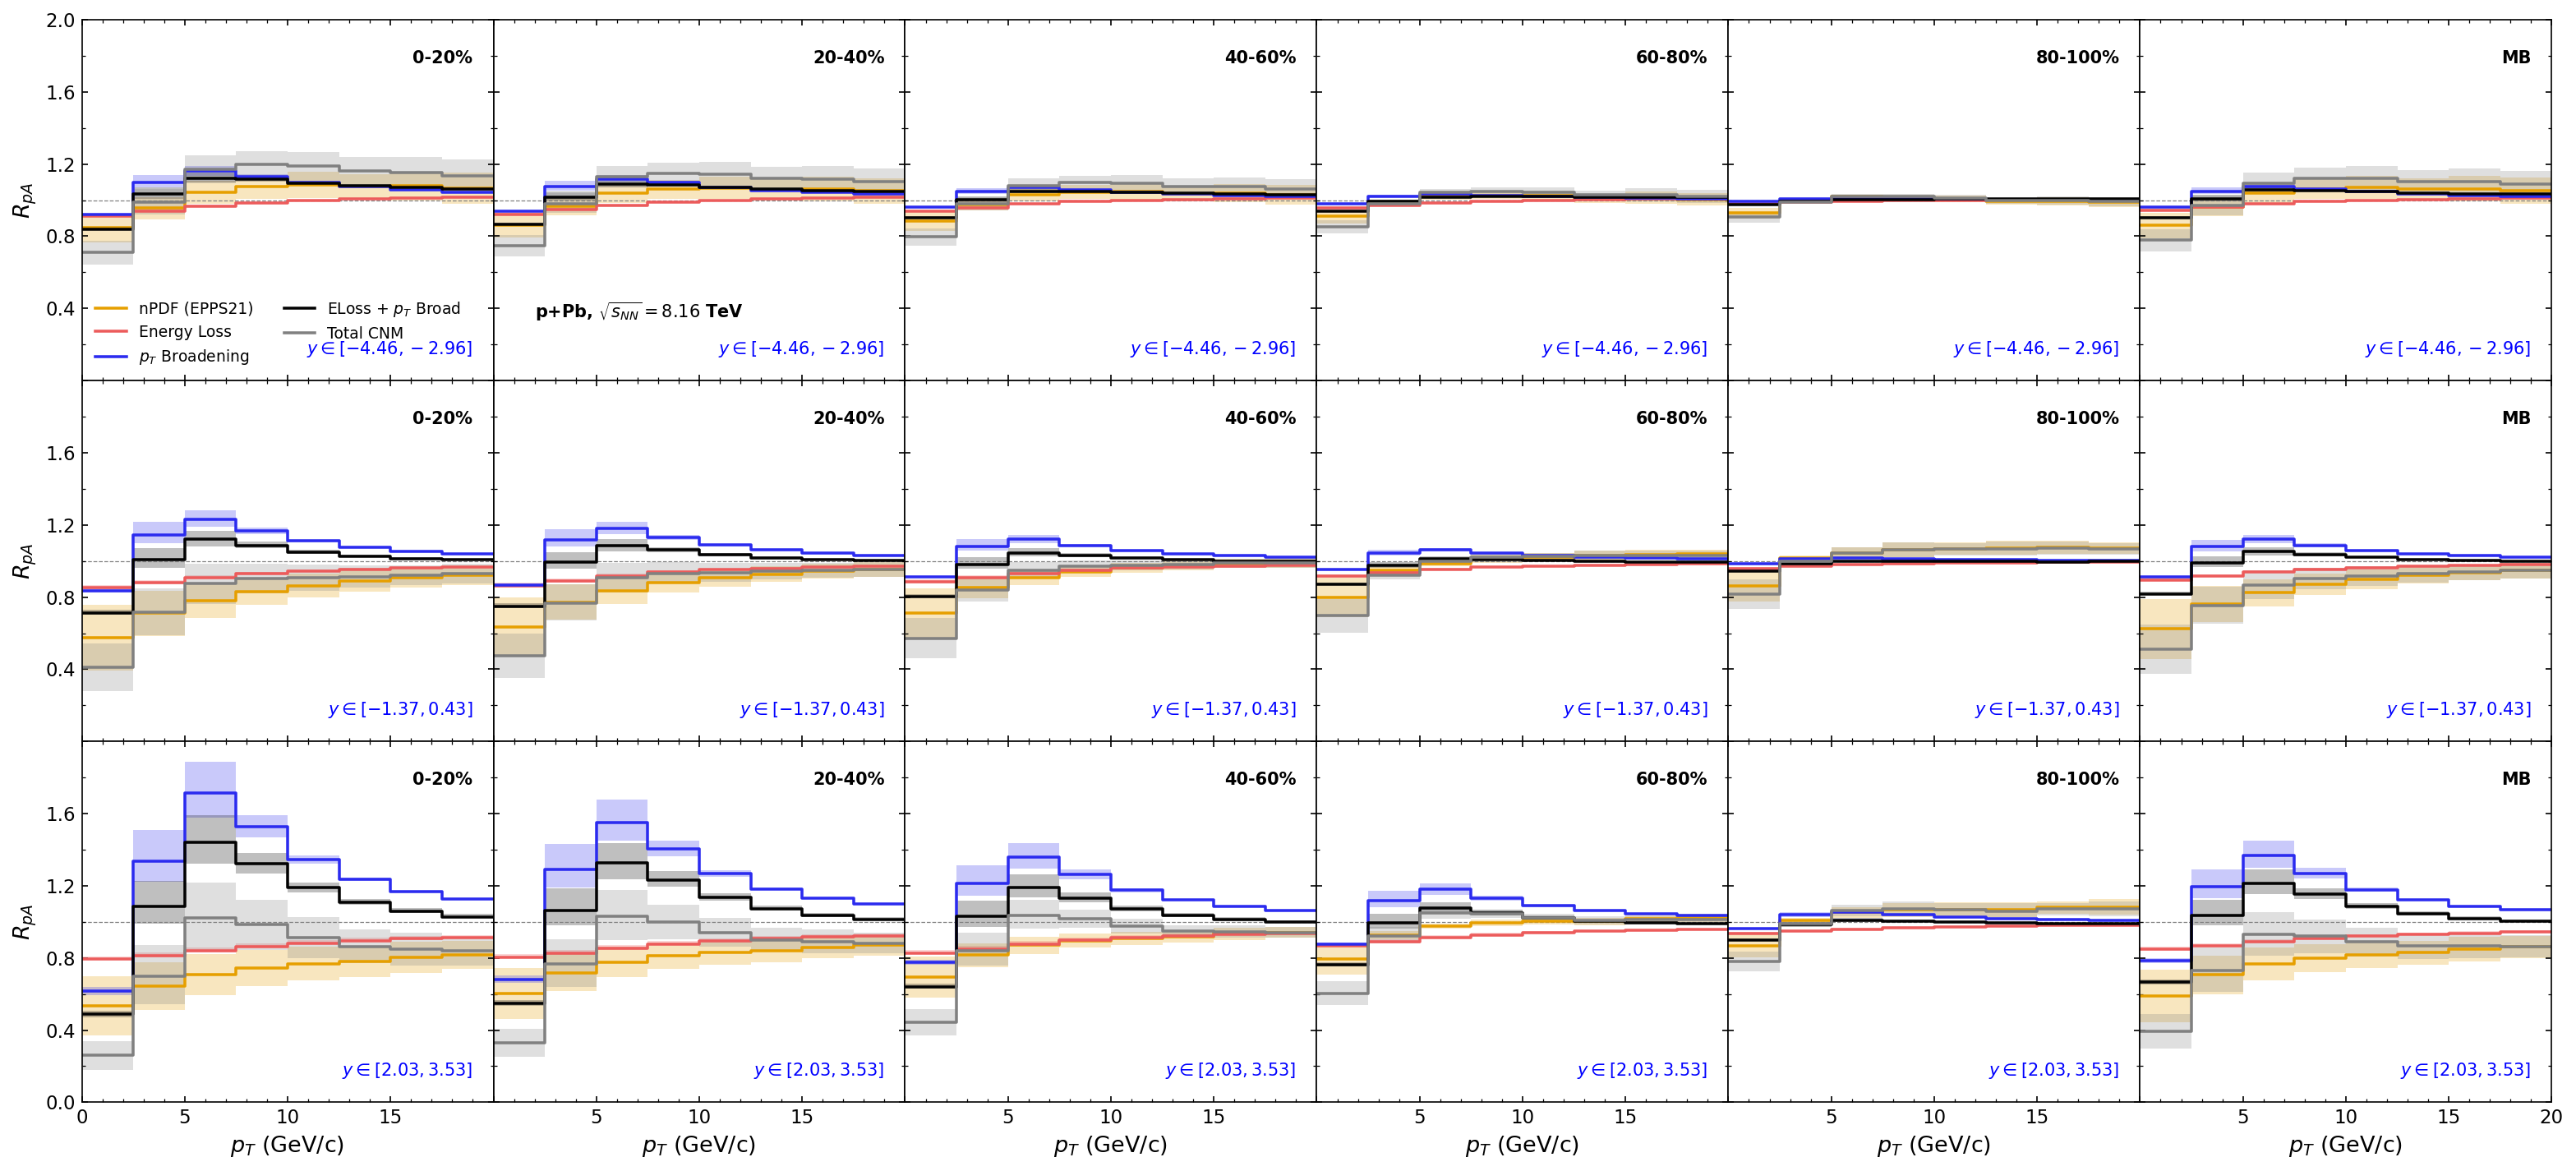

In [9]:
import matplotlib.ticker as ticker

for energy in energies:
    outdir = outdir_by_E[energy]
    print(f"[PLOT pT MASTER GRID] {energy} TeV ...")

    # correct dict keys for centrality panels
    _, labels_cent, _, _ = res_y[energy]
    cent_tags = labels_cent + ["MB"]
    ncols = len(cent_tags)

    y_windows = list(Config.rapidity_windows)
    nrows = len(y_windows)

    fig, axs = plt.subplots(
        nrows, ncols,
        figsize=(3.5*ncols, 3.2*nrows),
        dpi=DPI,
        sharex=True, sharey=True,
        gridspec_kw={"wspace": 0.0, "hspace": 0.0}
    )
    axs = np.atleast_2d(axs)

    # put system note once
    note_row, note_col = 0, (1 if ncols > 1 else 0)

    for irow, y_window in enumerate(y_windows):
        y0, y1 = y_window

        # cached pT result
        pT_cent, labels_pt, final_bands_pt, pT_edges = res_pt[energy][y_window]

        for jcol, tag in enumerate(cent_tags):
            ax = axs[irow, jcol]

            for comp in components:
                plot_component_band(ax, pT_cent, final_bands_pt, comp, tag, step=True)

            # styling
            ax.axhline(1.0, color="gray", lw=0.6, ls="--", zorder=1)
            ax.set_xlim(0, 20)
            ax.set_ylim(0.0, 2.0)
            ax.tick_params(direction="in", which="both", top=True, right=True, labelsize=11)
            ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
            ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
            ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

            # y-window label (bottom-right) on every panel
            ax.text(
                0.95, 0.06, rf"$y \in [{y0}, {y1}]$",
                transform=ax.transAxes, ha="right", va="bottom",
                fontsize=10, color="blue", fontweight="bold"
            )

            # centrality tag (top-right)
            ax.text(
                0.95, 0.88, "MB" if tag == "MB" else tag,
                transform=ax.transAxes, ha="right",
                fontweight="bold", fontsize=10
            )

            # outer labels only
            if irow == nrows - 1:
                ax.set_xlabel(r"$p_T$ (GeV/c)", fontsize=13)
            if jcol == 0:
                ax.set_ylabel(r"$R_{pA}$", fontsize=13)

            # system note once
            if (irow == note_row) and (jcol == note_col):
                ax.text(
                    0.1, 0.16, rf"p+Pb, $\sqrt{{s_{{NN}}}}={energy}$ TeV",
                    transform=ax.transAxes, ha="left", va="bottom",
                    fontsize=10, fontweight="bold"
                )

            # ---- prevent x tick-label overlap (bottom row only) ----
            if irow == nrows - 1:
                ticks = ax.xaxis.get_major_ticks()
                if jcol > 0:
                    ticks[0].label1.set_visible(False)   # hide leftmost label
                if jcol < ncols - 1:
                    ticks[-1].label1.set_visible(False)  # hide rightmost label

            # ---- prevent y tick-label overlap (left column only) ----
            if jcol == 0:
                yticks = ax.yaxis.get_major_ticks()
                if irow > 0:
                    yticks[-1].label1.set_visible(False)  # hide top label (overlap w panel above)
                if irow < nrows - 1:
                    yticks[0].label1.set_visible(False)   # hide bottom label (overlap w panel below)

    axs[0, 0].legend(loc="lower left", fontsize=9, frameon=False, ncol=2)

    fig.tight_layout()
    if SAVE_PDF:
        fig.savefig(outdir / f"RpA_vs_pT_MASTERGRID_{energy}TeV.pdf", bbox_inches="tight")
    plt.show()

## 3. $R_{pA}$ vs Centrality

In [10]:
for energy in energies:
    print(f"[CALC cent] {energy} TeV ...")
    cnm = cnm_by_E[energy]
    res_cent[energy] = {}

    for y_window in Config.rapidity_windows:
        y0, y1 = y_window
        res_cent[energy][y_window] = cnm.cnm_vs_centrality(
            (y0, y1),
            pt_range_avg=Config.pt_range_integrated
        )
    print("Cent calc done.")

[CALC cent] 5.02 TeV ...
Cent calc done.
[CALC cent] 8.16 TeV ...
Cent calc done.


[PLOT cent] 5.02 TeV ...


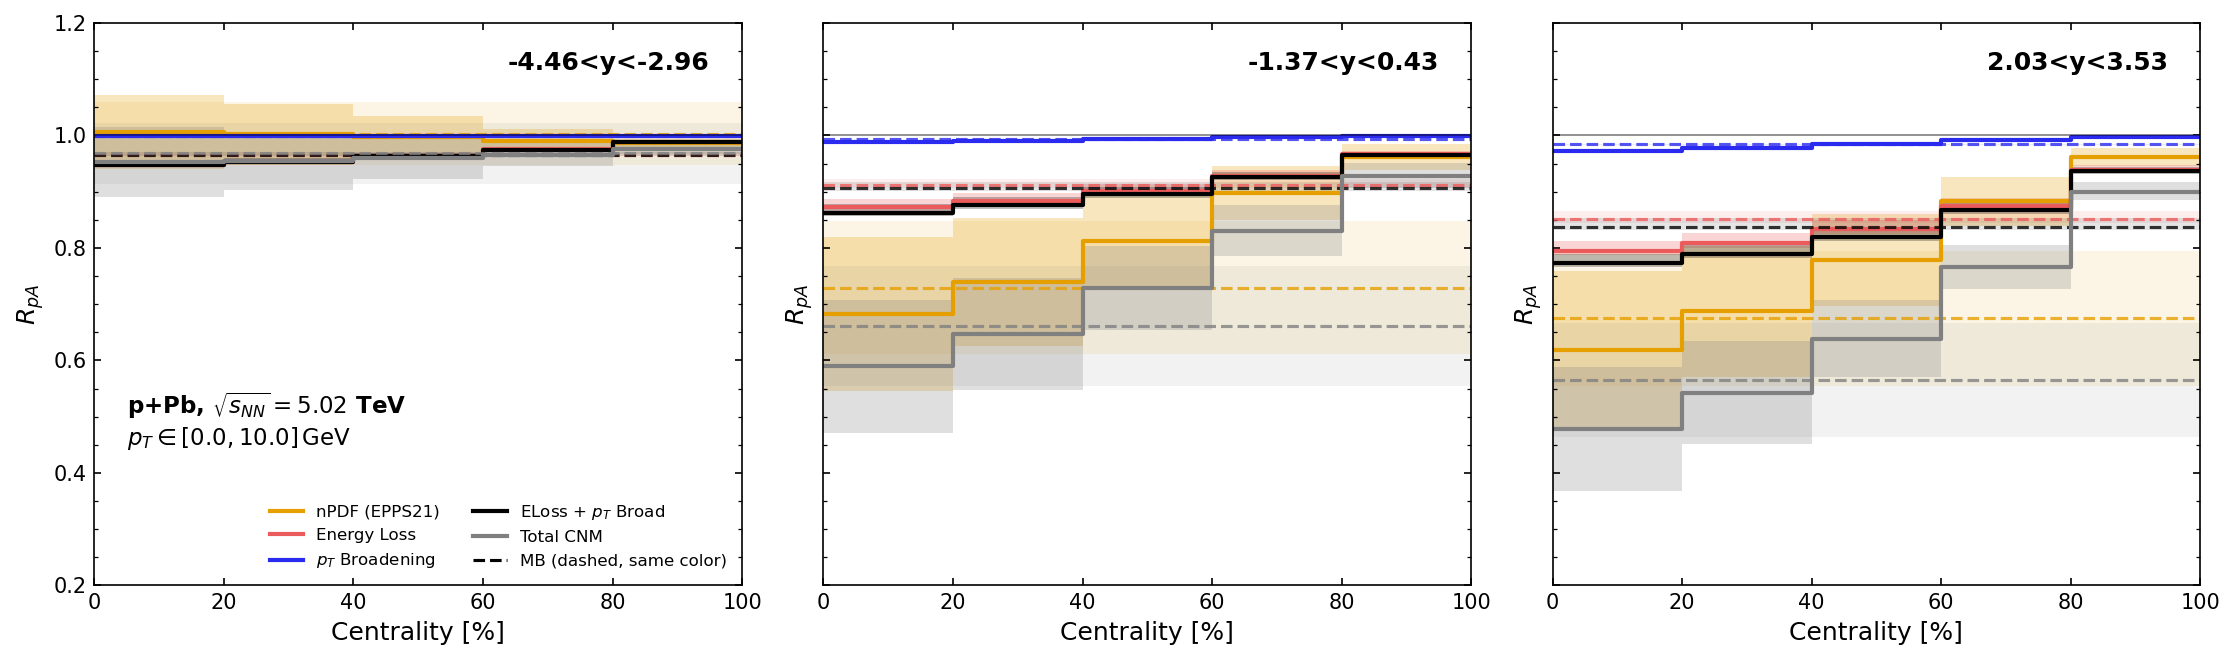

[PLOT cent] 8.16 TeV ...


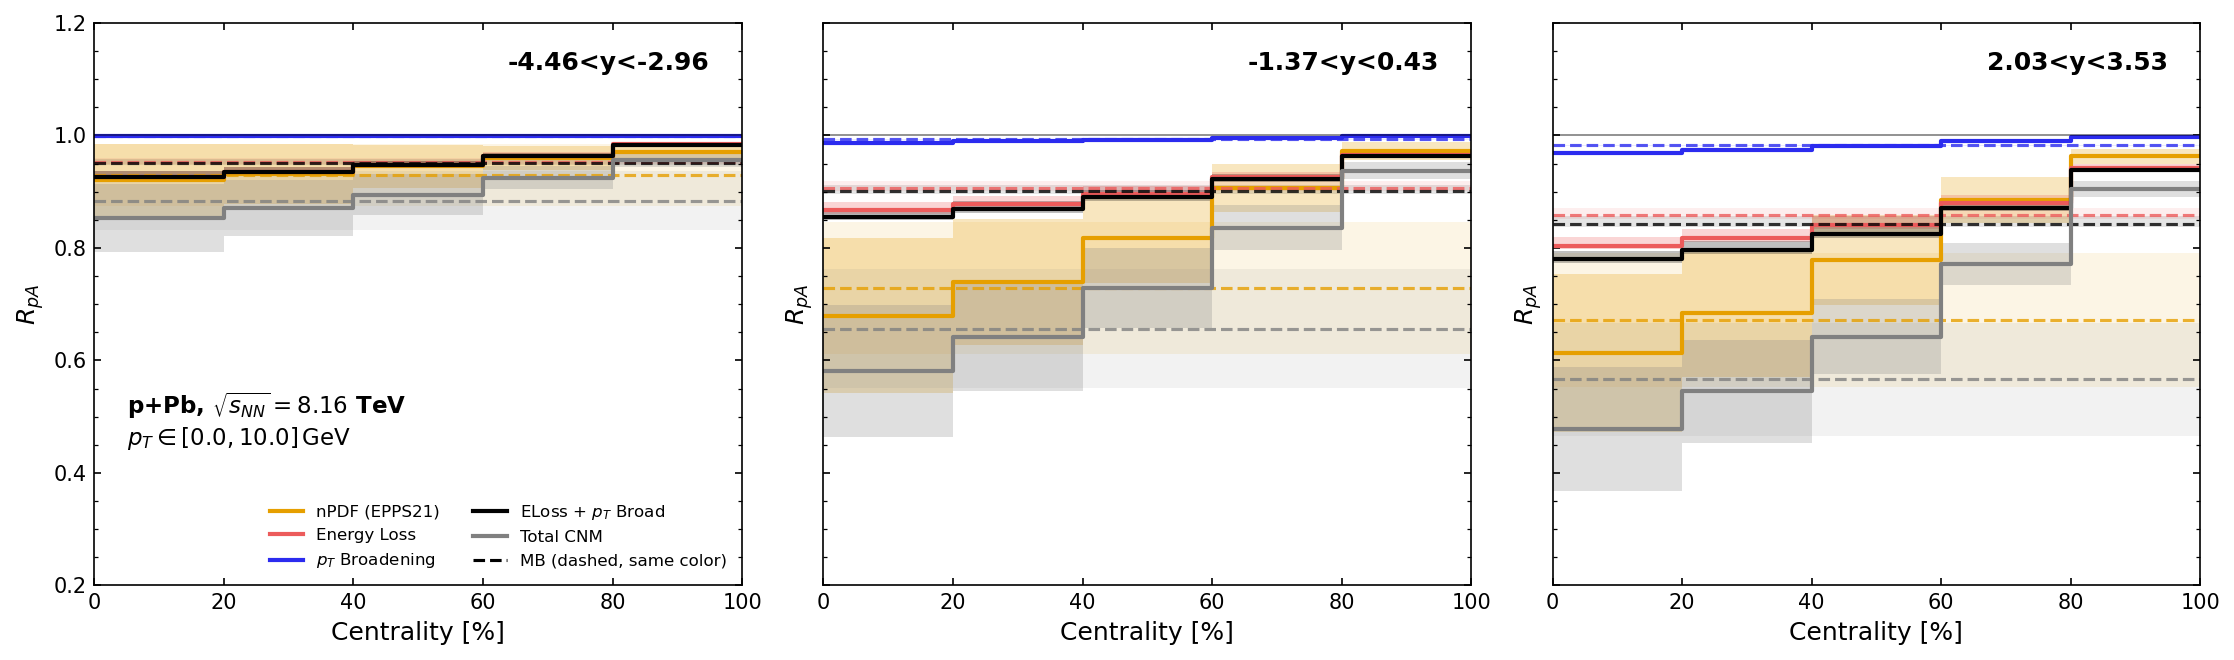

In [11]:
from matplotlib.lines import Line2D

# --- build centrality bin edges once ---
cent_bins = Config.cent_bins_plotting
x_edges = np.array([cent_bins[0][0]] + [b for (_, b) in cent_bins], dtype=float)

def cent_step(yvals):
    """Convert per-bin values (len N) -> step values (len N+1) for where='post'."""
    yvals = np.asarray(yvals, float)
    return np.r_[yvals, yvals[-1]]

# one legend handle to explain MB style (dashed line, same color as component)
mb_handle = Line2D([0], [0], color="k", lw=1.5, ls="--", label="MB (dashed, same color)")

for energy in energies:
    outdir = outdir_by_E[energy]
    print(f"[PLOT cent] {energy} TeV ...")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=DPI, sharey=True)

    for ax, y_window in zip(axes, Config.rapidity_windows):
        y0, y1 = y_window
        resC = res_cent[energy][y_window]

        for comp in components:
            color = COLORS[comp]
            label = COMP_LABELS[comp]
            vc, vl, vh, mbc, mbl, mbh = resC[comp]

            # --- STEP arrays ---
            y_c  = cent_step(vc)
            y_lo = cent_step(vl)
            y_hi = cent_step(vh)

            ax.step(x_edges, y_c, where="post", color=color, lw=2.0,
                    label=label if ax==axes[0] else None)
            ax.fill_between(x_edges, y_lo, y_hi, step="post",
                            color=color, alpha=ALPHA_BAND, lw=0)

            # --- MB dashed line + MB band ---
            ax.hlines(mbc, 0.0, 100.0, colors=color, linestyles="--", linewidth=1.5, alpha=0.8)
            ax.fill_between([0.0, 100.0], [mbl, mbl], [mbh, mbh],
                            color=color, alpha=0.1, lw=0)

        apply_pub_style(ax, (0, 100), (0.2, 1.2), 'Centrality [%]', r'$R_{pA}$',
                        tag=f"{y0}<y<{y1}")

        if ax == axes[0]:
            handles, labs = ax.get_legend_handles_labels()
            handles.append(mb_handle)
            labs.append(mb_handle.get_label())
            ax.legend(handles, labs, loc='lower right', fontsize=8, frameon=False, ncol=2)

            ax.text(0.05, 0.25,
                    rf"p+Pb, $\sqrt{{s_{{NN}}}} = {energy}$ TeV"
                    "\n"
                    rf"$p_T \in [{Config.pt_range_integrated[0]}, {Config.pt_range_integrated[1]}]\,\mathrm{{GeV}}$",
                    transform=ax.transAxes,
                    fontsize=11,
                    fontweight='bold')

    fig.tight_layout()
    if SAVE_PDF:
        fig.savefig(outdir / f'RpA_vs_centrality_all_components_{energy}TeV.pdf', bbox_inches='tight')
    plt.show()